# Imports

In [2]:
import os
import sys

In [3]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [4]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [6]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

In [7]:
# Huang 2018 
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
HD143006 = {'inc': 18.6, 'pa': 169, 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout': 0.518*3, 'disk_name': 'HD143006'}

In [8]:
best_Elias27 = {'m': -3.297430763696686, 'c': 316115113583956.4, 'l': 44039.6957302716}
best_AS209 = {'m': -1.3620915465005585, 'c': 4681.0681578390195, 'l': 72454.15132114716}


In [9]:
params =  {'m': -2, 'c': 1e8, 'l': 7e4}


In [12]:
data =  AS209

In [13]:

dir = "./../../data/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

# Frank Parameters
N = 300

# Load data
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j

uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

dir_fits =  "/Users/mariajmelladot/Desktop/Frank2D/data/fits/"
disk_fits = disk_name + '_continuum.fits'
fits_file = dir_fits + disk_fits

geom = Geometry(inc, pa, dra, ddec)
frank2d = Frank2D(N, rout, geom)

In [14]:
u.dtype

dtype('float64')

In [15]:
import os

os.environ["OMP_NUM_THREADS"] = "8"

In [16]:
import os
print(os.environ["OMP_NUM_THREADS"])

8


# Disk

In [17]:
frank2d.process_vis(uvtable)

Setting gridded data...


In [18]:
print(frank2d.gridded_data['vis'].dtype, type(frank2d.gridded_data['vis']))

complex128 <class 'numpy.ndarray'>


In [19]:
best_params = best_AS209

Setting GP Kernel Wendland...
Creating sparse linear system...
--> time kernel = 0.03  min |  1.98 seconds
--> time = 0.03  min |  2.04 seconds
Solving linear system...
         * rtol: 1e-08
         * final tolerance: 2.881751982790494
Final tolerance :  2.881751982790494
.... iteration:  0
                        -> actual tol:  288175198.2790494 vs  2.881751982790494
.... iteration:  1
                        -> actual tol:  26326009.765339248 vs  2.881751982790494
.... iteration:  2
                        -> actual tol:  23214242.497994628 vs  2.881751982790494
.... iteration:  3
                        -> actual tol:  23233630.869696684 vs  2.881751982790494
.... iteration:  4
                        -> actual tol:  23003242.462165065 vs  2.881751982790494
.... iteration:  5
                        -> actual tol:  22241933.797516476 vs  2.881751982790494
.... iteration:  6
                        -> actual tol:  23850510.82305613 vs  2.881751982790494
.... iteration:  7
        

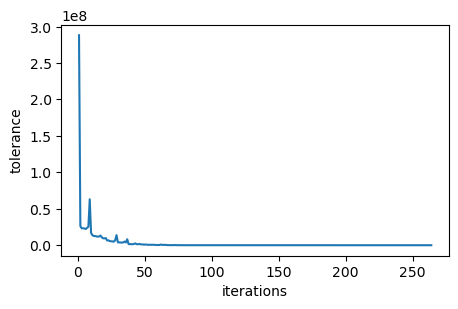

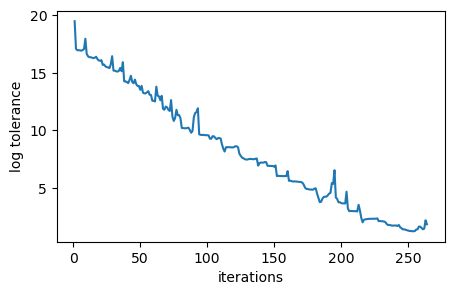

--> time = 0.14  min |  8.48 seconds
               ---> CGM converged?   True
                    ---> Fit correctly?   True
                     !!!!  Sucess..  !!!!
Building full visibility model...
--> times building full visibility model = 0.06  min |  3.87 seconds


In [20]:
frank2d.fit(kernel_params = best_params, rtol = 1e-8)

### Find M and $S^{-1}$ 

In [22]:
ME = MAPEstimator(frank2d._Rmax,  frank2d._Geometry, N = 50)

In [27]:
#data = uvtable
#u, v, vis, weights = data['u'], data['v'], data['vis'], data['weights']
#ME._FF.fit(u, v, vis, weights)

In [28]:
data = frank2d.gridded_data
u, v, vis, weights = data['u'], data['v'], data['vis'], data['weights']
ME._FF.fit(u, v, vis, weights)

In [29]:
GM = ME._FF.GaussianModel

In [31]:
M = GM._M

In [40]:
M.shape

(2500, 2500)

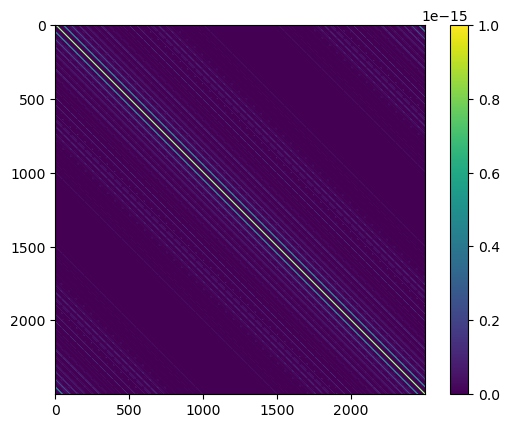

In [39]:
plt.imshow(M, vmin=0, vmax=1e-15)
plt.colorbar()

In [47]:
def sample_from_inv_cov_chol(M):
    L = np.linalg.cholesky(M)
    eta = np.random.randn(M.shape[0])
    z = np.linalg.solve(L, eta)  # equivale a L^{-1} eta
    return z

z_M = sample_from_inv_cov_chol(M)

* $S = F_{back}^{-1} \tilde{S} F_{back}$
* We want $z_S$ ~ $N(0, S^{-1})$, then solve with CGM $Sx = \eta$ with $\eta$~ N(0, I).

In [48]:
m, c, l = best_params['m'], best_params['c'], best_params['l']

In [50]:
S = GM.calculate_S_real_space(m, c, l)


In [54]:
# See github.
from scipy.sparse.linalg import LinearOperator, cg

def matvec_S(v):
    return S @ v

n = S.shape[0]

eta = np.random.randn(n)  # ~ N(0, I)

S_op = LinearOperator((n,n), matvec=matvec_S, dtype=np.float64)

z_S, info = cg(S_op, eta, maxiter=500)
# z_S ~ N(0, S^{-1})


In [55]:
z_S

array([ 2.58893096e-16,  1.13547971e-16,  3.99580896e-16, ...,
        4.18178882e-16, -2.83402710e-16, -3.20797452e-16])

In [56]:
z = z_M + z_S

Solve $D^{-1} x = j + z$ with CGM

In [58]:
j = GM._j

In [59]:
b = j + z

In [ ]:
x, info = cg(LinearOperator((n,n), matvec=lambda v: matvec_M(v) + matvec_S(v)), M_mu + z)
